# Expert Labels

In [1]:
import scripts
import numpy as np

In [64]:
theme = ['#0283F8', '#0078F3', '#3369E8', '#605BDA', "#7D49CB",
          "#9331B7", "#A918A8", "#C4009A", "#DA008B", "#EA007B",
          "#F7006A", "#FF0059"]

In [2]:
import sys
import os
import warnings
from contextlib import contextmanager

@contextmanager
def suppress_stdout_stderr():
    """A context manager that redirects stdout and stderr to devnull"""
    # Save the original stdout and stderr
    original_stdout = sys.stdout
    original_stderr = sys.stderr
    
    # Open the null device
    with open(os.devnull, 'w') as devnull:
        # Redirect stdout and stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield # This is where the code inside the 'with' block will run
        finally:
            # IMPORTANT: Always restore the original streams
            sys.stdout = original_stdout
            sys.stderr = original_stderr

import csv
import os

def append_dict_to_csv(csv_filepath, data_dict):
    """
    Appends a dictionary as a new row to a CSV file.

    - If the CSV file does not exist, it will be created, and the
      dictionary keys will be used as the header row.
    - If the CSV file exists, the dictionary values are appended
      as a new row. The keys are assumed to match the header.

    Args:
        csv_filepath (str): The path to the CSV file.
        data_dict (dict): The dictionary to write to the CSV.
    """
    # Check if the file exists to determine if we need to write the header
    file_exists = os.path.exists(csv_filepath)

    # Use 'a' mode for appending, which creates the file if it doesn't exist.
    # newline='' is critical to prevent blank rows from being written.
    with open(csv_filepath, 'a', newline='', encoding='utf-8') as f:
        # The fieldnames are the dictionary keys.
        # It's important that all dictionaries you write have the same keys.
        fieldnames = data_dict.keys()
        
        # Create a DictWriter object
        writer = csv.DictWriter(f, fieldnames=fieldnames)

        # If the file is new, write the header row
        if not file_exists:
            writer.writeheader()

        # Write the dictionary as a new row
        writer.writerow(data_dict)
        
def append_df_to_csv(csv_filepath, df, index=False):
    """
    Appends a pandas DataFrame to a CSV file.

    - If the CSV file does not exist, it's created, and the DataFrame's
      column names are used as the header.
    - If the CSV file exists, the DataFrame's data is appended without
      writing a new header.

    Args:
        csv_filepath (str): The path to the CSV file.
        df (pd.DataFrame): The DataFrame to append.
        index (bool): Write DataFrame index as a column. Defaults to False.
    """
    # Check if the file exists to determine if the header needs to be written.
    header = not os.path.exists(csv_filepath)

    # Use pandas to_csv function with mode 'a' (append)
    # and the header parameter controlled by file existence.
    df.to_csv(
        csv_filepath, 
        mode='a', 
        header=header, 
        index=index,
        encoding='utf-8'
    )

In [7]:
# Load the data
def load_dataset(dataset="adult",expert_accuracy=0.75,seed=42):
    if dataset=="adult":
        df,y,feature_names = scripts.datasets.adult_load_and_preprocess()
    elif dataset== "plant":
        df,y,feature_names = scripts.datasets.plant_load_and_preprocess()
    elif dataset=="telescope":
        df,y,feature_names = scripts.datasets.telescope_load_and_preprocess()
    elif dataset=="wine":
        df,y,feature_names = scripts.datasets.wine_load_and_preprocess()
    elif dataset=="broward":
        return load_broward_dataset()
    elif dataset=="diabetes":
        df,y,feature_names = scripts.datasets.diabetes_load_and_preprocess()
    else:
        print("ERROR: dataset has to be one of [adult, plant,wine]")
        return
            
    np.random.seed(seed)
    feature_weights = {feature: [np.random.randint(0,2), 0] for feature in feature_names}
    
    expert = scripts.expert.simulate_expert(
        X_processed=df,
        y_true=y,
        feature_weights_config=feature_weights,
        target_fnr=1-expert_accuracy, 
        target_fpr=1-expert_accuracy,
        expert_alpha=30,
        expert_seed=seed
    )
    
    human_predictions = expert.predict(df,y)
    dataset = scripts.datasets.Dataset(df.values,y,human_predictions,random_seed=seed) #put seed here too ma man
    return expert, dataset, feature_names

In [8]:
import torch
from defer.helpers.metrics import *
from defer.networks.linear_net import *
from defer.networks.non_linear_net import *
import torch.optim as optim
from defer.methods.realizable_surrogate import *
from defer.baselines.lce_surrogate import *
from defer.baselines.one_v_all import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import os

def train_l2d_model(dataset, expert,method = "realizable_surrogate"):
    # Set up model training parameters
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    optimizer = optim.Adam
    scheduler = None
    lr = 1e-2
    total_epochs = 100
    # Create and train model
    model = NonLinearNet(dataset.d, 3).to(device)  # positive, negative, and defer
    # Instantiate method
    if method=="realizable_surrogate":
        L2D = RealizableSurrogate(1, 300, model, device, True)
    elif method== "crossentropy_surrogate": #lce
        L2D = LceSurrogate(1, 300, model, device)
    elif method== "one_vs_all":
        L2D = OVASurrogate(1, 300, model, device)
    else:
        print("Model has to be one of: realizable_surrogate, crossentropy_surrogate or one_vs_all")
        return None, {}, None, []
    L2D.fit_hyperparam(
        dataset.data_train_loader,
        dataset.data_val_loader,
        dataset.data_test_loader,
        epochs=total_epochs,
        optimizer=optimizer,
        scheduler=scheduler,
        lr=lr,
        verbose=False,
        test_interval=5,
    )
    # Get metrics
    metrics = compute_deferral_metrics(L2D.test(dataset.data_test_loader))
    factual_df, factuals = scripts.utils.build_factual_df(L2D,dataset,expert,defer_only=True)
    return L2D, metrics, factual_df, factuals

In [9]:

def obtain_counterfactuals(l2d,factuals,factual_df,metrics,expert):
    perturbations, counter_df = scripts.counterfactual.find_defer_counterfactuals_parallel(
        model=l2d.model,
        test_x=factuals,
        threshold_rej=0,
        n_jobs=-1 # Use all available cores
    )
    
    counter_df = scripts.utils.probe_counterfactuals(counter_df,perturbations,factuals,expert,l2d)
    df_merged = factual_df.join(counter_df[["cfs_entropy","cfs_expected_expert_err"]],how="inner")
    
    isTypeI = df_merged["entropy"] > df_merged["cfs_entropy"]
    isTypeII = df_merged["cfs_expected_expert_err"] > df_merged["expected_expert_err"]
    #model_was_correct = df_merged["model_pred"] == df_merged["label"]
    #expert_was_correct = df_merged["expert_pred"] == df_merged["label"]
    
    metrics["n_type1"] = np.sum(isTypeI)
    metrics["n_type2"] = np.sum(isTypeII)
    metrics["n_only_type1"] = np.sum(isTypeI & ~isTypeII)
    metrics["n_only_type2"] = np.sum(isTypeII & ~isTypeI)
    metrics["n_defer"] = df_merged.shape[0]
    return metrics,df_merged, perturbations



    

In [10]:
import time

def run_expert_iteration(dataset_name="adult", method="realizable_surrogate",max_retries=10):
    seed = int(time.time())
    max_retries = 10 # Safety measure to prevent infinite loops

    expert_accuracies = [0.6,0.625, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
    i = 0 # Our manual loop index

    while i < len(expert_accuracies):
        expert_acc = expert_accuracies[i]
        print(f"Running: {expert_acc} accuracy on {dataset_name} using {method} with seed {seed}...")
        with suppress_stdout_stderr():
            expert, dataset, feature_names = load_dataset(dataset=dataset_name, expert_accuracy=expert_acc, seed=seed)
            RS, metrics, factual_df, factuals = train_l2d_model(dataset, expert,method = method)
        if len(factuals)==0: # Or `if factuals.empty:` for pandas DataFrames
            print(f"--> No factuals found. Changing seed and retrying for expert_acc={expert_acc}...")
            seed = int(time.time()) # Change the seed and try again
            continue
        with suppress_stdout_stderr():
            metrics, counter_df, perturbations = obtain_counterfactuals(RS, factuals,factual_df, metrics, expert)
        append_dict_to_csv(f"results/validation_expert_{dataset_name}_{method}.csv", metrics)
        i += 1

In [12]:
dataset="adult" #adult
method = "crossentropy_surrogate" #realizable_surrogate
for i in range(1):
    print("-"*10+f" Iteration {i} "+"-"*10)
    run_expert_iteration(dataset,method)

---------- Iteration 0 ----------
Running: 0.6 accuracy on adult using crossentropy_surrogate with seed 1753704244...
--> No factuals found. Changing seed and retrying for expert_acc=0.6...
Running: 0.6 accuracy on adult using crossentropy_surrogate with seed 1753704441...
--> No factuals found. Changing seed and retrying for expert_acc=0.6...
Running: 0.6 accuracy on adult using crossentropy_surrogate with seed 1753704669...
Running: 0.625 accuracy on adult using crossentropy_surrogate with seed 1753704669...
Running: 0.65 accuracy on adult using crossentropy_surrogate with seed 1753704669...
Running: 0.7 accuracy on adult using crossentropy_surrogate with seed 1753704669...
Running: 0.75 accuracy on adult using crossentropy_surrogate with seed 1753704669...
Running: 0.8 accuracy on adult using crossentropy_surrogate with seed 1753704669...
Running: 0.85 accuracy on adult using crossentropy_surrogate with seed 1753704669...
Running: 0.9 accuracy on adult using crossentropy_surrogate w

In [14]:
data = pd.read_csv(f"results/validation_expert_{dataset_name}_{method}.csv")

In [33]:
for method in ["realizable_surrogate","crossentropy_surrogate","one_vs_all"]:
    seed = int(time.time())
    dataset_list = ["adult","plant","wine"]
    i=0
    while i < len(dataset_list):
        dataset_name=dataset_list[i]
        print(f"Running: {dataset_name} using {method} with seed {seed}...")
        with suppress_stdout_stderr():
            expert, dataset, feature_names = load_dataset(dataset=dataset_name, expert_accuracy=0.75, seed=seed)
            RS, metrics, factual_df, factuals = train_l2d_model(dataset, expert,method = method)
        if len(factuals)==0: # Or `if factuals.empty:` for pandas DataFrames
            print(f"--> No factuals found. Changing seed and retrying for dataset={dataset_list}...")
            seed = int(time.time()) # Change the seed and try again
            continue
        with suppress_stdout_stderr():
            metrics, counter_df, perturbations = obtain_counterfactuals(RS, factuals,factual_df, metrics, expert)
        #save and continue
        counter_df["dataset"] = dataset_name;counter_df["method"] = method
        append_df_to_csv(f"results/baseline_boxplot.csv", counter_df)
        #save perturbations and factuals
        perturbations = np.array([p.detach().numpy().flatten() for p in perturbations])
        factuals = np.array([f.detach().numpy().flatten() for f in factuals])
        np.save(f'results/perturbations_{dataset_name}_{method}.npy', perturbations)
        np.save(f'results/factuals_{dataset_name}_{method}.npy', factuals)
        i+=1

Running: adult using realizable_surrogate with seed 1753800723...
Running: plant using realizable_surrogate with seed 1753800723...
Running: telescope using realizable_surrogate with seed 1753800723...
Running: wine using realizable_surrogate with seed 1753800723...
Running: adult using crossentropy_surrogate with seed 1753802580...
Running: plant using crossentropy_surrogate with seed 1753802580...
Running: telescope using crossentropy_surrogate with seed 1753802580...
Running: wine using crossentropy_surrogate with seed 1753802580...
Running: adult using one_vs_all with seed 1753804724...
Running: plant using one_vs_all with seed 1753804724...
Running: telescope using one_vs_all with seed 1753804724...
Running: wine using one_vs_all with seed 1753804724...


In [84]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_method_comparison(baseline, method_name, metric_type='expert', ax=None):
    """
    Create boxplots comparing factual and counterfactual metrics across datasets.
    
    Parameters:
    -----------
    baseline : pd.DataFrame
        The baseline dataframe containing the data
    method_name : str
        The method to filter by (e.g., 'realizable_surrogate')
    metric_type : str
        Either 'expert' or 'entropy' to determine which columns to plot
    figsize : tuple
        Figure size (width, height)
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    
    # Define column mappings and labels
    column_mappings = {
        'expert': {
            'columns': ['expected_expert_err', 'cfs_expected_expert_err'],
            'ylabel': 'Expected Expert Perf.'
        },
        'entropy': {
            'columns': ['entropy', 'cfs_entropy'],
            'ylabel': 'Confidence'
        }
    }
    
    # Validate metric_type
    if metric_type not in column_mappings:
        raise ValueError(f"metric_type must be either 'expert' or 'entropy', got '{metric_type}'")
    
    # Get the columns and label for the selected metric
    var_columns = column_mappings[metric_type]['columns']
    y_label = column_mappings[metric_type]['ylabel']
    
    if ax is None:
        # Create the plot
        fig, ax = plt.subplots(figsize=(8, 3))
    
    # Filter data for the specified method
    df_melted = baseline[baseline['method'] == method_name].copy()
    
    # Get unique datasets
    datasets = ["adult", "plant", "wine"]
    n_datasets = len(datasets)
    
    # Create positions for boxplots
    positions = []
    dataset_centers = []
    gap = 1  # Gap between datasets
    
    for i, dataset in enumerate(datasets):
        # Two positions for factual and counterfactual, with small gap between them
        pos_a = i * (2 + gap)
        pos_b = i * (2 + gap) + 1
        positions.extend([pos_a, pos_b])
        
        # Center position for dataset label
        dataset_centers.append((pos_a + pos_b) / 2)
    
    # Prepare data for each boxplot
    plot_data = []
    plot_labels = []
    
    for dataset in datasets:
        for var in var_columns:
            data_subset = df_melted[df_melted['dataset'] == dataset][var]
            plot_data.append(1-data_subset.values)
            plot_labels.append(f'{dataset}_{var}')
    
    # Create boxplots
    bp = ax.boxplot(plot_data, positions=positions, patch_artist=True)
    
    # Color the boxplots (alternating colors for factual and counterfactual)
    colors = [theme[0], theme[-1]]
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(colors[i % 2])
        patch.set_alpha(0.3)
    
    # Set x-axis labels (dataset names at center positions)
    ax.set_xticks(dataset_centers)
    ax.set_xticklabels(datasets)
    
    
    # Customize the plot
    ax.set_ylabel(y_label)
    ax.spines[["top", "right"]].set_visible(False)
    
    # Optional: Add subtle vertical lines to separate datasets
    for i in range(1, n_datasets):
        separator_x = dataset_centers[i-1] + (dataset_centers[i] - dataset_centers[i-1])/2
        ax.axvline(x=separator_x, color='gray', linestyle='--', alpha=0.3)
    

In [85]:
baseline = pd.read_csv(f"results/baseline_boxplot.csv")

In [167]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from scipy import stats

def plot_method_comparison(baseline, method_name, metric_type='expert', ax=None):
    """
    Create boxplots comparing factual and counterfactual metrics across datasets.
    
    Parameters:
    -----------
    baseline : pd.DataFrame
        The baseline dataframe containing the data
    method_name : str
        The method to filter by (e.g., 'realizable_surrogate')
    metric_type : str
        Either 'expert' or 'entropy' to determine which columns to plot
    figsize : tuple
        Figure size (width, height)
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    
    # Define column mappings and labels
    column_mappings = {
        'expert': {
            'columns': ['expected_expert_err', 'cfs_expected_expert_err'],
            'ylabel': 'Expected Expert Perf.'
        },
        'entropy': {
            'columns': ['entropy', 'cfs_entropy'],
            'ylabel': 'Uncertainty'
        }
    }
    
    # Validate metric_type
    if metric_type not in column_mappings:
        raise ValueError(f"metric_type must be either 'expert' or 'entropy', got '{metric_type}'")
    
    # Get the columns and label for the selected metric
    var_columns = column_mappings[metric_type]['columns']
    y_label = column_mappings[metric_type]['ylabel']
    
    if ax is None:
        # Create the plot
        fig, ax = plt.subplots(figsize=(8, 3))
    
    # Filter data for the specified method
    df_melted = baseline[baseline['method'] == method_name].copy()
    
    # Get unique datasets
    datasets = ["adult", "plant", "wine"]
    n_datasets = len(datasets)
    
    # Create positions for boxplots
    positions = []
    dataset_centers = []
    gap = 1  # Gap between datasets
    
    for i, dataset in enumerate(datasets):
        # Two positions for factual and counterfactual, with small gap between them
        pos_a = i * (2 + gap)
        pos_b = i * (2 + gap) + 1
        positions.extend([pos_a, pos_b])
        
        # Center position for dataset label
        dataset_centers.append((pos_a + pos_b) / 2)
    
    # Prepare data for each boxplot
    plot_data = []
    plot_labels = []
    
    for dataset in datasets:
        for var in var_columns:
            data_subset = df_melted[df_melted['dataset'] == dataset][var]
            if metric_type=="expert":
                plot_data.append(1-data_subset.values)
            else:
                plot_data.append(data_subset.values)
            plot_labels.append(f'{dataset}_{var}')
    
    # Create boxplots
    bp = ax.boxplot(plot_data, positions=positions, patch_artist=True)
    
    # Color the boxplots (alternating colors for factual and counterfactual)
    colors = ["#1F77B4", "#C7DDED"]
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(colors[i % 2])
        patch.set_alpha(1)  # Make boxes more opaque
        patch.set_edgecolor('black')  # Black box outlines
        patch.set_linewidth(1.2)
    
    # Make all lines black
    for element in ['whiskers', 'caps', 'medians', 'fliers']:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(1.2)
    
    # Set x-axis labels (dataset names at center positions)
    ax.set_xticks(dataset_centers)
    ax.set_xticklabels(datasets)
    
    # Customize the plot
    ax.set_ylabel(y_label)
    ax.spines[["top", "right"]].set_visible(False)
    
    # Add statistical significance markers
    add_statistical_significance_markers(baseline, method_name, metric_type, ax)
    
    # Optional: Add subtle vertical lines to separate datasets
    for i in range(1, n_datasets):
        separator_x = dataset_centers[i-1] + (dataset_centers[i] - dataset_centers[i-1])/2
        ax.axvline(x=separator_x, color='gray', linestyle='--', alpha=0.3)


def add_statistical_significance_markers(baseline, method_name, metric_type='expert', ax=None):
    """
    Test distribution pairs and add statistical significance markers between distributions.
    
    Parameters:
    -----------
    baseline : pd.DataFrame
        The baseline dataframe containing the data
    method_name : str
        The method to filter by
    metric_type : str
        Either 'expert' or 'entropy' to determine which columns to test
    ax : matplotlib.axes.Axes
        The axes object to add markers to
    
    Returns:
    --------
    dict : Dictionary with test results for each dataset
    """
    
    # Define column mappings
    column_mappings = {
        'expert': {
            'columns': ['expected_expert_err', 'cfs_expected_expert_err'],
        },
        'entropy': {
            'columns': ['entropy', 'cfs_entropy'],
        }
    }
    
    var_columns = column_mappings[metric_type]['columns']
    df_melted = baseline[baseline['method'] == method_name].copy()
    datasets = ["adult", "plant", "wine"]
    
    results = {}
    
    # Create positions matching the boxplot function
    positions = []
    gap = 1
    for i, dataset in enumerate(datasets):
        pos_a = i * (2 + gap)
        pos_b = i * (2 + gap) + 1
        positions.extend([pos_a, pos_b])
    
    for i, dataset in enumerate(datasets):
        # Get data for both conditions
        data1 = df_melted[df_melted['dataset'] == dataset][var_columns[0]]
        data2 = df_melted[df_melted['dataset'] == dataset][var_columns[1]]
        
        # Transform data the same way as in the plot
        data1_transformed = data1.values
        data2_transformed = data2.values
        
        # Perform Mann-Whitney U test
        statistic, p_value = stats.mannwhitneyu(data1_transformed, data2_transformed, alternative='two-sided')
        
        # Determine significance
        if p_value < 0.001:
            sig_marker = '***'
        elif p_value < 0.01:
            sig_marker = '**'
        elif p_value < 0.05:
            sig_marker = '*'
        else:
            sig_marker = 'ns'
        
        results[dataset] = {
            'statistic': statistic,
            'p_value': p_value,
            'significance': sig_marker,
            'significant': p_value < 0.05
        }
        
        # Add markers to plot if ax is provided
        if ax is not None:
            pos1 = positions[i * 2]
            pos2 = positions[i * 2 + 1]
            
            # Find max y value for positioning
            y_max = max(np.max(data1_transformed), np.max(data2_transformed))
            y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
            y_offset = y_range * 0.05
            
            # Draw significance marker
            line_y = y_max + y_offset
            ax.plot([pos1, pos2], [line_y, line_y], 'k-', linewidth=1)
            
            # Add ticks
            tick_height = y_offset * 0.3
            ax.plot([pos1, pos1], [line_y - tick_height, line_y + tick_height], 'k-', linewidth=1)
            ax.plot([pos2, pos2], [line_y - tick_height, line_y + tick_height], 'k-', linewidth=1)
            
            # Add text
            mid_x = (pos1 + pos2) / 2
            ax.text(mid_x, line_y + y_offset * 0.5, sig_marker, 
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    return results

In [238]:
method="one_vs_all"

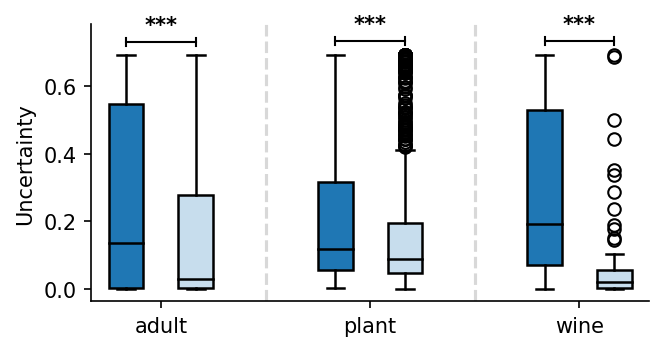

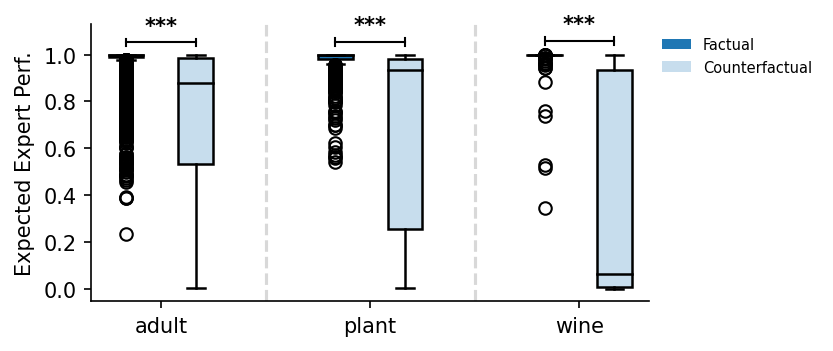

In [239]:
fig, ax = plt.subplots(figsize=(4.8,2.4),sharex=True,dpi=150)
plot_method_comparison(baseline, method, 'entropy',ax=ax)
plt.savefig(f"results/fig2_{method}_distributions_unc.pdf",bbox_inches = 'tight')
plt.show()
fig, ax = plt.subplots(figsize=(4.8,2.4),sharex=True,dpi=150)
plot_method_comparison(baseline, method, 'expert',ax=ax)
# Add legend
legend_elements = [
    Patch(facecolor="#1F77B4", label='Factual'),
    Patch(facecolor= "#C7DDED", label='Counterfactual')
]
ax.legend(handles=legend_elements,frameon=False,bbox_to_anchor=(1, 1.0),fontsize=7)
plt.savefig(f"results/fig2_{method}_distributions_exp.pdf",bbox_inches = 'tight')
plt.show()

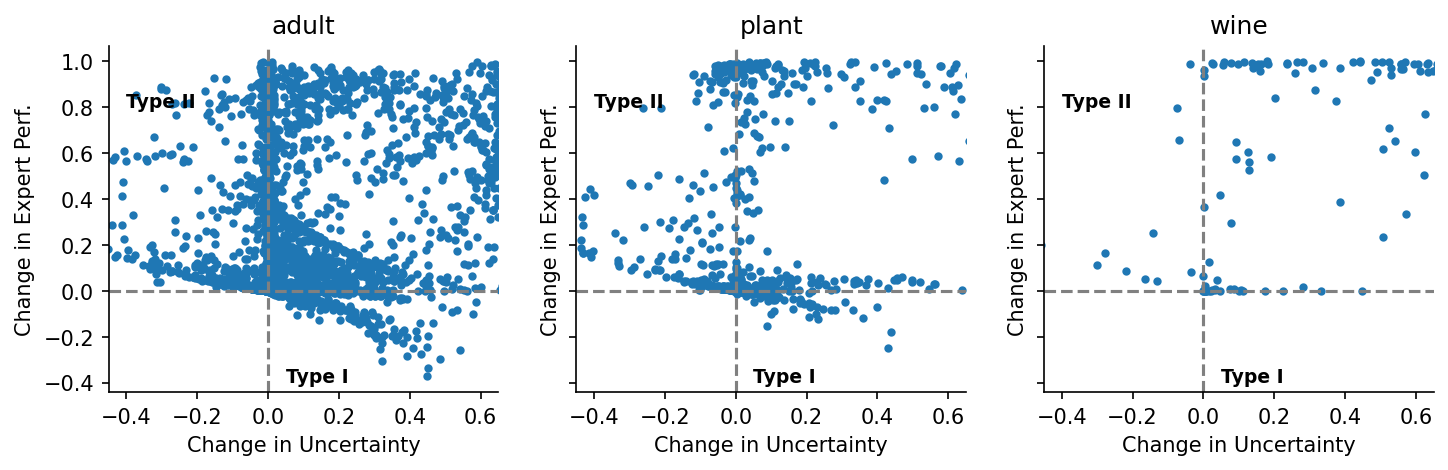

In [240]:
fig, ax = plt.subplot_mosaic("ABC",figsize=(11.4,3),sharey=True,dpi=150)


df = baseline[(baseline['dataset'] == "adult") & (baseline['method'] == method)]

ax["A"].scatter(df["entropy"]- df["cfs_entropy"],
            df["cfs_expected_expert_err"]-df["expected_expert_err"],marker=".")


ax["A"].set_xlabel("Change in Uncertainty")
ax["A"].set_ylabel("Change in Expert Perf.")
ax["A"].axvline(0,linestyle="--",color="gray")
ax["A"].axhline(0,linestyle="--",color="gray")
ax["A"].annotate("Type I",(0.05,-0.4),fontsize=9, weight="bold")
ax["A"].annotate("Type II",(-0.4,0.8),fontsize=9, weight="bold")
ax["A"].spines[["top","right"]].set_visible(False)
ax["A"].set_xlim(-0.45,0.65)
ax["A"].set_title("adult")

df = baseline[(baseline['dataset'] == "plant") & (baseline['method'] == method)]

ax["B"].scatter(df["entropy"]- df["cfs_entropy"],
            df["cfs_expected_expert_err"]-df["expected_expert_err"],marker=".")


ax["B"].set_xlabel("Change in Uncertainty")
ax["B"].set_ylabel("Change in Expert Perf.")
ax["B"].axvline(0,linestyle="--",color="gray")
ax["B"].axhline(0,linestyle="--",color="gray")
ax["B"].annotate("Type I",(0.05,-0.4),fontsize=9, weight="bold")
ax["B"].annotate("Type II",(-0.4,0.8),fontsize=9, weight="bold")
ax["B"].spines[["top","right"]].set_visible(False)
ax["B"].set_xlim(-0.45,0.65)
ax["B"].set_title("plant")

df = baseline[(baseline['dataset'] == "wine") & (baseline['method'] == method)]

ax["C"].scatter(df["entropy"]- df["cfs_entropy"],
            df["cfs_expected_expert_err"]-df["expected_expert_err"],marker=".")


ax["C"].set_xlabel("Change in Uncertainty")
ax["C"].set_ylabel("Change in Expert Perf.")
ax["C"].axvline(0,linestyle="--",color="gray")
ax["C"].axhline(0,linestyle="--",color="gray")
ax["C"].annotate("Type I",(0.05,-0.4),fontsize=9, weight="bold")
ax["C"].annotate("Type II",(-0.4,0.8),fontsize=9, weight="bold")
ax["C"].spines[["top","right"]].set_visible(False)
ax["C"].set_xlim(-0.45,0.65)
ax["C"].set_title("wine")
plt.savefig(f"results/fig2_{method}_coords_change.pdf",bbox_inches = 'tight')
plt.show()

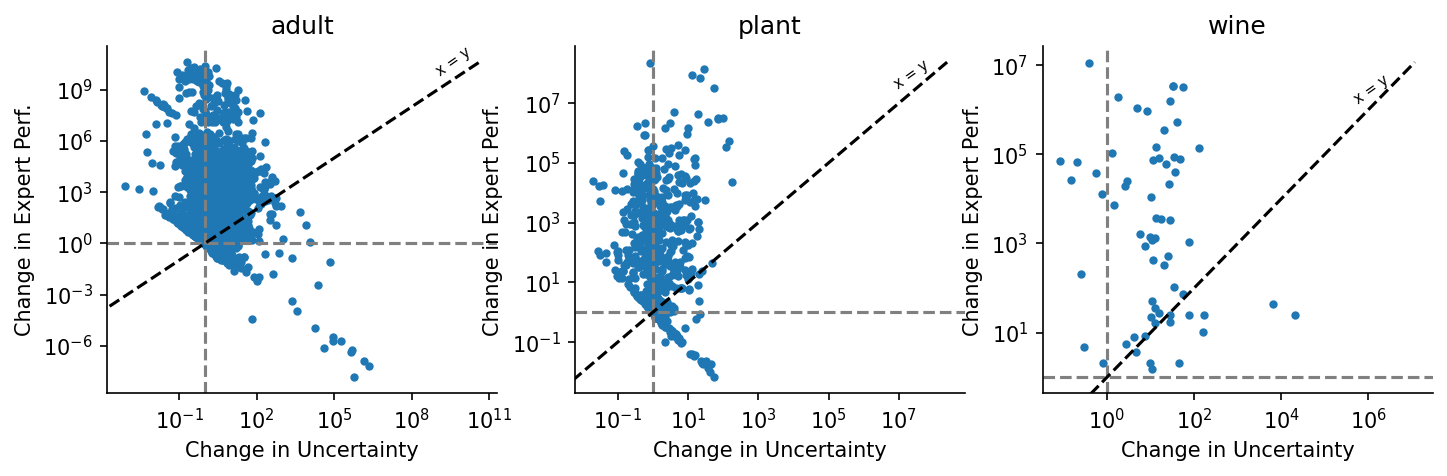

In [241]:
fig, ax = plt.subplot_mosaic("ABC",figsize=(11.4,3),dpi=150)


df = baseline[(baseline['dataset'] == "adult") & (baseline['method'] == method)]

ax["A"].scatter(df["entropy"]/df["cfs_entropy"],
            df["cfs_expected_expert_err"]/df["expected_expert_err"],marker=".")


ax["A"].set_xlabel("Change in Uncertainty")
ax["A"].set_ylabel("Change in Expert Perf.")
ax["A"].axvline(1,linestyle="--",color="gray")
ax["A"].axhline(1,linestyle="--",color="gray")
ax["A"].annotate("Type I",(0.05,-0.4),fontsize=9, weight="bold")
ax["A"].annotate("Type II",(-0.4,0.8),fontsize=9, weight="bold")
ax["A"].spines[["top","right"]].set_visible(False)
#ax["A"].set_xlim(-0.45,0.65)
ax["A"].set_title("adult")
xmin, xmax = ax["A"].get_xlim()
ymin, ymax = ax["A"].get_ylim()

# Find the overall min and max, so the line spans the entire plot
plot_min = min(xmin, ymin)
plot_max = max(xmax, ymax)

# Plot the y=x line
ax["A"].plot([plot_min, plot_max], [plot_min, plot_max], 
        color='black', linestyle='--', linewidth=1.5, 
        label='y = x', zorder=2)
ax["A"].text(plot_max/10, plot_max/10, 'x = y', rotation=35, 
             ha='center', va='bottom', 
             fontsize=7, color='black')
ax["A"].set_yscale("log")
ax["A"].set_xscale("log")



df = baseline[(baseline['dataset'] == "plant") & (baseline['method'] == method)]

ax["B"].scatter(df["entropy"]/df["cfs_entropy"],
            df["cfs_expected_expert_err"]/df["expected_expert_err"],marker=".")


ax["B"].set_xlabel("Change in Uncertainty")
ax["B"].set_ylabel("Change in Expert Perf.")
ax["B"].axvline(1,linestyle="--",color="gray")
ax["B"].axhline(1,linestyle="--",color="gray")
ax["B"].annotate("Type I",(0.05,-0.4),fontsize=9, weight="bold")
ax["B"].annotate("Type II",(-0.4,0.8),fontsize=9, weight="bold")
ax["B"].spines[["top","right"]].set_visible(False)
#ax["B"].set_xlim(-0.45,0.65)
ax["B"].set_title("plant")
xmin, xmax = ax["B"].get_xlim()
ymin, ymax = ax["B"].get_ylim()
# Find the overall min and max, so the line spans the entire plot
plot_min = min(xmin, ymin)
plot_max = max(xmax, ymax)
# Plot the y=x line
ax["B"].plot([plot_min, plot_max], [plot_min, plot_max], 
        color='black', linestyle='--', linewidth=1.5, 
        label='y = x', zorder=2)
ax["B"].text(plot_max/10, plot_max/10, 'x = y', rotation=35, 
             ha='center', va='bottom', 
             fontsize=7, color='black')
ax["B"].set_yscale("log")
ax["B"].set_xscale("log")

df = baseline[(baseline['dataset'] == "wine") & (baseline['method'] == method)]

ax["C"].scatter(df["entropy"]/df["cfs_entropy"],
            df["cfs_expected_expert_err"]/df["expected_expert_err"],marker=".")


ax["C"].set_xlabel("Change in Uncertainty")
ax["C"].set_ylabel("Change in Expert Perf.")
ax["C"].axvline(1,linestyle="--",color="gray")
ax["C"].axhline(1,linestyle="--",color="gray")
ax["C"].annotate("Type I",(0.05,-0.4),fontsize=9, weight="bold")
ax["C"].annotate("Type II",(-0.4,0.8),fontsize=9, weight="bold")
ax["C"].spines[["top","right"]].set_visible(False)
#ax["C"].set_xlim(-0.45,0.65)
ax["C"].set_title("wine")
xmin, xmax = ax["C"].get_xlim()
ymin, ymax = ax["C"].get_ylim()
# Find the overall min and max, so the line spans the entire plot
plot_min = min(xmin, ymin)
plot_max = max(xmax, ymax)
# Plot the y=x line
ax["C"].plot([plot_min, plot_max], [plot_min, plot_max], 
        color='black', linestyle='--', linewidth=1.5, 
        label='y = x', zorder=2)
ax["C"].text(plot_max/10, plot_max/10, 'x = y', rotation=35, 
             ha='center', va='bottom', 
             fontsize=7, color='black',
             zorder=3)
ax["C"].set_yscale("log")
ax["C"].set_xscale("log")
plt.savefig(f"results/fig2_{method}_coords_change_ratio.pdf",bbox_inches = 'tight')
plt.show()

# Plausability

Running: adult using crossentropy_surrogate with seed 1754065503...
Processing 6422 samples for defer counterfactuals in parallel...
Running: plant using crossentropy_surrogate with seed 1754065503...
Processing 1549 samples for defer counterfactuals in parallel...
Running: wine using crossentropy_surrogate with seed 1754065503...
Processing 174 samples for defer counterfactuals in parallel...


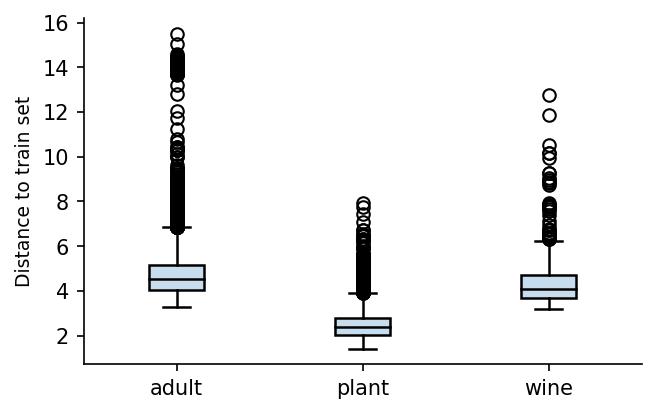

Running: adult using one_vs_all with seed 1754068199...
Processing 5026 samples for defer counterfactuals in parallel...
Running: plant using one_vs_all with seed 1754068199...
Processing 1088 samples for defer counterfactuals in parallel...
Running: wine using one_vs_all with seed 1754068199...
Processing 98 samples for defer counterfactuals in parallel...


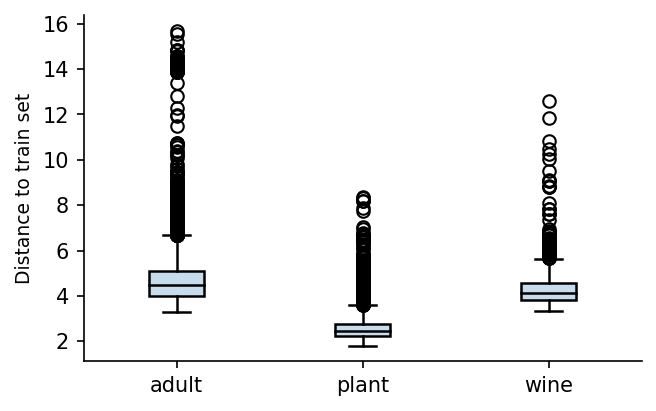

In [318]:

from scipy.spatial.distance import cdist

for method in ["crossentropy_surrogate","one_vs_all"]:#,"crossentropy_surrogate","one_vs_all"
    plausability = []
    seed = int(time.time())
    dataset_list = ["adult","plant","wine"]#,"plant","wine"
    i=0
    while i < len(dataset_list):
        dataset_name=dataset_list[i]
        print(f"Running: {dataset_name} using {method} with seed {seed}...")
        with suppress_stdout_stderr():
            expert, dataset, feature_names = load_dataset(dataset=dataset_name, expert_accuracy=0.75, seed=seed)
            RS, metrics, factual_df, factuals = train_l2d_model(dataset, expert,method = method)
        if len(factuals)==0: # Or `if factuals.empty:` for pandas DataFrames
            print(f"--> No factuals found. Changing seed and retrying for dataset={dataset_list}...")
            seed = int(time.time()) # Change the seed and try again
            continue
       
        perturbations, counter_df = scripts.counterfactual.find_defer_counterfactuals_parallel(
            model=RS.model,
            test_x=factuals,
            threshold_rej=0,
            n_jobs=-1 # Use all available cores
        )

        temp = counter_df.dropna(subset=["defer_cf_index"]).copy()
        counterfactuals = np.array(
                [factuals[i].detach().numpy() + perturbations[j].flatten().numpy() for i,j in zip(temp['sample_index'],temp["defer_cf_index"])]
            )
        dist_mat = np.hstack([cdist(counterfactuals,train_x) for train_x, _, _ in dataset.data_train_loader])
        plausability.append(dist_mat.mean(axis=0))
        i+=1
        
    fig, ax = plt.subplots(figsize=(4.8,3),dpi=150)
    bp = ax.boxplot(plausability,labels=["adult","plant","wine"],patch_artist=True)

    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor("#C7DDED")
        patch.set_alpha(1)  # Make boxes more opaque
        patch.set_edgecolor('black')  # Black box outlines
        patch.set_linewidth(1.2)

    # Make all lines black
    for element in ['whiskers', 'caps', 'medians', 'fliers']:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(1.2)

    ax.spines[["top","right"]].set_visible(False)
    ax.set_ylabel("Distance to train set", fontsize=9)
    plt.savefig(f"results/plausability_{method}.pdf")
    plt.show()